# 훈련 세트와 테스트 세트

<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/rickiepark/hg-mldl2/blob/main/02-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

## 훈련 세트와 테스트 세트

In [1]:
fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8,
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7,
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

In [2]:
fish_data = [[l, w] for l, w in zip(fish_length, fish_weight)]
fish_target = [1]*35 + [0]*14

In [3]:
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier()

In [ ]:
print(fish_data[4])

[29.0, 430.0]


In [ ]:
print(fish_data[0:5])

[[25.4, 242.0], [26.3, 290.0], [26.5, 340.0], [29.0, 363.0], [29.0, 430.0]]


In [ ]:
print(fish_data[:5])

[[25.4, 242.0], [26.3, 290.0], [26.5, 340.0], [29.0, 363.0], [29.0, 430.0]]


In [ ]:
print(fish_data[44:])

[[12.2, 12.2], [12.4, 13.4], [13.0, 12.2], [14.3, 19.7], [15.0, 19.9]]


In [4]:
train_input = fish_data[:35]
train_target = fish_target[:35]

test_input = fish_data[35:]
test_target = fish_target[35:]

In [6]:
kn.fit(train_input, train_target)
kn.score(test_input, test_target)
#앞에 35개는 도미고 뒤에 14개는 빙어기 때문에 score는 0점 --> randaom으로 해야함 (데이터가 골고루 섞이게)


0.0

## 넘파이

In [7]:
import numpy as np #섞기

In [8]:
input_arr = np.array(fish_data)
target_arr = np.array(fish_target)

In [9]:
print(input_arr)

[[  25.4  242. ]
 [  26.3  290. ]
 [  26.5  340. ]
 [  29.   363. ]
 [  29.   430. ]
 [  29.7  450. ]
 [  29.7  500. ]
 [  30.   390. ]
 [  30.   450. ]
 [  30.7  500. ]
 [  31.   475. ]
 [  31.   500. ]
 [  31.5  500. ]
 [  32.   340. ]
 [  32.   600. ]
 [  32.   600. ]
 [  33.   700. ]
 [  33.   700. ]
 [  33.5  610. ]
 [  33.5  650. ]
 [  34.   575. ]
 [  34.   685. ]
 [  34.5  620. ]
 [  35.   680. ]
 [  35.   700. ]
 [  35.   725. ]
 [  35.   720. ]
 [  36.   714. ]
 [  36.   850. ]
 [  37.  1000. ]
 [  38.5  920. ]
 [  38.5  955. ]
 [  39.5  925. ]
 [  41.   975. ]
 [  41.   950. ]
 [   9.8    6.7]
 [  10.5    7.5]
 [  10.6    7. ]
 [  11.     9.7]
 [  11.2    9.8]
 [  11.3    8.7]
 [  11.8   10. ]
 [  11.8    9.9]
 [  12.     9.8]
 [  12.2   12.2]
 [  12.4   13.4]
 [  13.    12.2]
 [  14.3   19.7]
 [  15.    19.9]]


In [13]:
print(input_arr.shape)

(49, 2)


In [44]:
#np.random.seed(42)
index = np.arange(49)
np.random.shuffle(index)

In [45]:
print(index)

[45 36 47  3 11 17 15 18 16  9 33 23  4 13 20 30  7 46 43  2  8 41 32 26
  0 39 24 48 25 10 40 29 19 34 37  5  1 27 21  6 31 12 35 28 42 14 44 38
 22]


In [46]:
print(input_arr[[1,3]])

[[ 26.3 290. ]
 [ 29.  363. ]]


In [47]:
train_input = input_arr[index[:35]]
train_target = target_arr[index[:35]]

In [48]:
print(input_arr[13], train_input[0])

[ 32. 340.] [12.4 13.4]


In [49]:
test_input = input_arr[index[35:]]
test_target = target_arr[index[35:]]

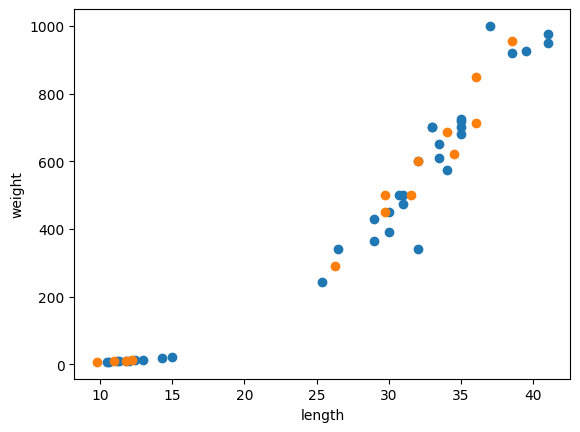

In [50]:
import matplotlib.pyplot as plt

plt.scatter(train_input[:, 0], train_input[:, 1]) #2차원 배열이기 때문에 행렬 크기 지정
plt.scatter(test_input[:, 0], test_input[:, 1])
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

## 두 번째 머신러닝 프로그램

In [51]:
kn.fit(train_input, train_target)

KNeighborsClassifier()

In [52]:
kn.score(test_input, test_target)

1.0

In [53]:
kn.predict(test_input)

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1])

In [54]:
test_target

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1])